In [24]:
from pathlib import Path
import numpy as np

OUTDIR = Path("abtem_noise_outputs")
OUTDIR.mkdir(exist_ok=True)

rng = np.random.default_rng(0)  # use for Poisson noise so runs are repeatable

# Sanity check: confirm abTEM is installed and show the exact Python env VSCode is using.

import sys

try:
    import abtem
    print("abtem ok:", abtem.__version__)          # abTEM version (for reproducibility)
    print("python:", sys.version.split()[0])       # Python version
    print("executable:", sys.executable)           # Interpreter path (ensures correct conda env)
except Exception as e:
    print("abtem import failed:", repr(e))         # If this fails, install abTEM in this env

import numpy as np
import abtem
from ase.build import bulk

# Force CPU execution (avoid GPU dependency / keep behavior consistent).
abtem.config.set({"device": "cpu"})

# Build a tiny fcc Ni supercell (fast) just to test abTEM output ordering/shape.
atoms = bulk("Ni", "fcc", a=3.52) * (4, 4, 2)
atoms = abtem.orthogonalize_cell(atoms)  # make cell orthogonal for cleaner scanning bounds

# Create multislice potential (sampling controls real-space grid resolution vs speed).
potential = abtem.Potential(atoms, sampling=0.2)

# Define probe (accelerating voltage + convergence semi-angle).
probe = abtem.Probe(energy=200e3, semiangle_cutoff=30)
probe.grid.match(potential)  # ensure probe grid matches potential grid

# Define scan extent over one unit-cell area (Lx, Ly) and a small scan grid.
Lx, Ly, _ = atoms.cell.lengths()
scan = abtem.GridScan(
    start=(0.0, 0.0),
    end=(Lx, Ly),
    gpts=(8, 6),            # scan grid requested in abTEM order; we infer output order from result
    endpoint=False,
    potential=potential,
)

# Pixelated detector produces a full diffraction pattern per scan position.
det = abtem.PixelatedDetector(max_angle=60)

# Run 4D-STEM simulation and convert to a NumPy array.
meas = probe.scan(potential, scan=scan, detectors=det).compute()
arr = np.asarray(meas.array)

# Print the raw ordering so we can transpose to required (scan_y, scan_x, diff_y, diff_x).
print("raw shape:", arr.shape)
print("raw dtype:", arr.dtype)



abtem ok: 1.0.6
python: 3.10.13
executable: /Users/kylexu/miniconda3/envs/matsci465/bin/python
[########################################] | 100% Completed | 314.22 ms
raw shape: (8, 6, 69, 69)
raw dtype: float32


In [25]:
import numpy as np
import abtem
from ase.build import bulk
import matplotlib.pyplot as plt

# --- Simulation parameters (keep small for speed; increase later if needed) ---
energy_eV = 200e3          # accelerating voltage (200 kV)
semiangle_mrad = 30.0      # probe convergence semi-angle
max_angle_mrad = 60.0      # detector max scattering angle
sampling_A = 0.2           # potential sampling in Å (larger = faster, less accurate)

# Scan grid (final saved ordering is (scan_y, scan_x, diff_y, diff_x)).
nx, ny = 32, 32

# Crystal supercell (larger = more realistic, slower).
rep = (12, 12, 2)
a_A = 3.52                 # Ni fcc lattice parameter (Å)

# Noise / disorder knobs
rattle_stdev_A = 0.02      # Å, thermal disorder; set 0.0 to disable
dose_per_dp = 1e6          # electrons per diffraction pattern; increase = less noise

abtem.config.set({"device": "cpu"})

# Build pure matrix structure (Ni only).
atoms = bulk("Ni", "fcc", a=a_A) * rep
atoms = abtem.orthogonalize_cell(atoms)

# Add thermal disorder to break perfect periodicity.
if rattle_stdev_A > 0:
    atoms.rattle(stdev=rattle_stdev_A, seed=0)

# Build potential + probe and match grids.
potential = abtem.Potential(atoms, sampling=sampling_A)
probe = abtem.Probe(energy=energy_eV, semiangle_cutoff=semiangle_mrad)
probe.grid.match(potential)

# Define scan and pixelated detector (full DP per position).
Lx, Ly, _ = atoms.cell.lengths()
scan = abtem.GridScan(
    start=(0.0, 0.0),
    end=(Lx, Ly),
    gpts=(nx, ny),          # abTEM raw: (scan_x, scan_y, ky, kx)
    endpoint=False,
    potential=potential,
)
det = abtem.PixelatedDetector(max_angle=max_angle_mrad)

# Run simulation.
meas = probe.scan(potential, scan=scan, detectors=det).compute()
arr = np.asarray(meas.array, dtype=np.float32)                 # (nx, ny, ky, kx)
data4d = np.transpose(arr, (1, 0, 2, 3)).astype(np.float32)    # (ny, nx, ky, kx)

# Add Poisson shot noise per diffraction pattern (dose normalization).
dp_sum = data4d.sum(axis=(2, 3), keepdims=True) + 1e-12
scale = dose_per_dp / dp_sum
data4d = rng.poisson(data4d * scale).astype(np.float32) / scale

print("matrix data4d shape:", data4d.shape, "dtype:", data4d.dtype)

# Save matrix-only dataset.
np.save(OUTDIR / "abtem_matrix.npy", data4d)

# Save quick visual checks (mean DP + one example DP).
mean_dp = data4d.mean(axis=(0, 1))
ex_dp = data4d[ny // 2, nx // 2]

def _save_dp_png(dp, fname):
    plt.figure()
    plt.imshow(np.log1p(dp), origin="lower")
    plt.axis("off")
    plt.tight_layout(pad=0)
    plt.savefig(fname, dpi=200)
    plt.close()

_save_dp_png(mean_dp, OUTDIR / "mean_dp_matrix.png")
_save_dp_png(ex_dp, OUTDIR / "example_dp_matrix.png")

print("saved:", OUTDIR / "abtem_matrix.npy", OUTDIR / "mean_dp_matrix.png", OUTDIR / "example_dp_matrix.png")

[########################################] | 100% Completed | 12.61 ss
matrix data4d shape: (32, 32, 190, 190) dtype: float32
saved: abtem_noise_outputs/abtem_matrix.npy abtem_noise_outputs/mean_dp_matrix.png abtem_noise_outputs/example_dp_matrix.png


shape: (32, 32, 190, 190)
dtype: float32
min/max: 0.0 0.0008236641297116876
mean: 2.6842533770832233e-05


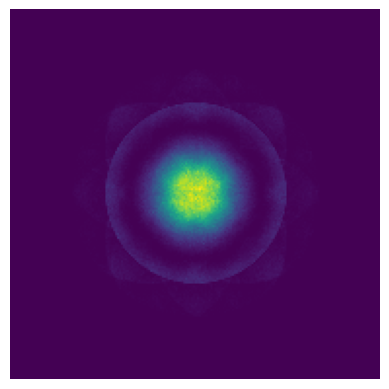

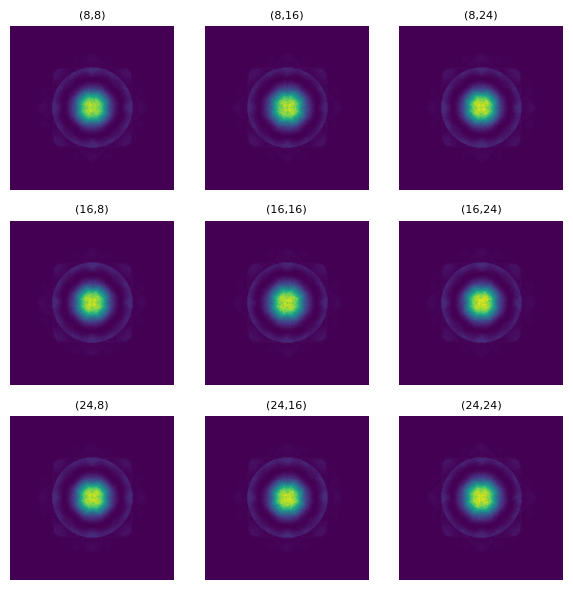

(8, 8) mean|diff| = 3.0105059067864204e-06
(8, 16) mean|diff| = 2.583588639026857e-06
(16, 8) mean|diff| = 3.1354431939689675e-06
(24, 24) mean|diff| = 2.1721414213971e-06


In [26]:
# Quick sanity check: load the saved matrix-only dataset and confirm basic stats.

import numpy as np

x = np.load(OUTDIR / "abtem_matrix.npy")   # (ny, nx, ky, kx)
print("shape:", x.shape)
print("dtype:", x.dtype)
print("min/max:", float(x.min()), float(x.max()))
print("mean:", float(x.mean()))

# Visualize one diffraction pattern from the 4D dataset (single scan position).

import numpy as np
import matplotlib.pyplot as plt

x = np.load(OUTDIR / "abtem_matrix.npy")          # (ny, nx, ky, kx)
dp = x[x.shape[0] // 2, x.shape[1] // 2]          # center scan pixel

plt.figure()
plt.imshow(np.log1p(dp), origin="lower")
plt.axis("off")
plt.show()

# Visualize multiple diffraction patterns across the scan (checks scan-to-scan variation).

import numpy as np
import matplotlib.pyplot as plt

x = np.load(OUTDIR / "abtem_matrix.npy")  # (ny, nx, ky, kx)
ny, nx, ky, kx = x.shape

ys = [ny // 4, ny // 2, 3 * ny // 4]
xs = [nx // 4, nx // 2, 3 * nx // 4]

fig, axes = plt.subplots(3, 3, figsize=(6, 6))
for i, y in enumerate(ys):
    for j, x0 in enumerate(xs):
        dp = x[y, x0]
        axes[i, j].imshow(np.log1p(dp), origin="lower")
        axes[i, j].set_title(f"({y},{x0})", fontsize=8)
        axes[i, j].axis("off")

plt.tight_layout()
plt.show()

# Sanity check that they are not exactly the same

import numpy as np
from pathlib import Path

x = np.load(OUTDIR / "abtem_matrix.npy")

# Compare a few positions to the center
ref = x[x.shape[0]//2, x.shape[1]//2]
for y, x0 in [(8,8),(8,16),(16,8),(24,24)]:
    diff = np.mean(np.abs(x[y, x0] - ref))
    print((y, x0), "mean|diff| =", float(diff))

In [27]:
import json
import numpy as np
import abtem
from ase.build import bulk
import matplotlib.pyplot as plt

abtem.config.set({"device": "cpu"})

# --- Keep these consistent with the matrix-only run (so comparisons are fair) ---
energy_eV = 200e3
semiangle_mrad = 30.0
max_angle_mrad = 60.0
sampling_A = 0.2

nx, ny = 32, 32
rep = (12, 12, 2)
a_A = 3.52

# Noise / disorder knobs
rattle_stdev_A = 0.05
dose_per_dp = 2e5
# -------------------------------------------------------------------------------

def save_dp_png(dp, fname):
    plt.figure()
    plt.imshow(np.log1p(dp), origin="lower")
    plt.axis("off")
    plt.tight_layout(pad=0)
    plt.savefig(fname, dpi=200)
    plt.close()

# Build Ni matrix and define a W-rich cylindrical precipitate by Ni->W substitution.
atoms = bulk("Ni", "fcc", a=a_A) * rep
atoms = abtem.orthogonalize_cell(atoms)

# Add thermal disorder to break perfect periodicity.
if rattle_stdev_A > 0:
    atoms.rattle(stdev=rattle_stdev_A, seed=0)

Lx, Ly, Lz = atoms.cell.lengths()
cx, cy = Lx / 2.0, Ly / 2.0
r_precip_A = 0.18 * min(Lx, Ly)

pos = atoms.get_positions()
in_cyl = (pos[:, 0] - cx) ** 2 + (pos[:, 1] - cy) ** 2 <= r_precip_A ** 2
symbols = np.array(atoms.get_chemical_symbols(), dtype=object)
symbols[in_cyl] = "W"
atoms.set_chemical_symbols(symbols.tolist())

# Simulate 4D-STEM.
potential = abtem.Potential(atoms, sampling=sampling_A)
probe = abtem.Probe(energy=energy_eV, semiangle_cutoff=semiangle_mrad)
probe.grid.match(potential)

scan = abtem.GridScan(
    start=(0.0, 0.0),
    end=(Lx, Ly),
    gpts=(nx, ny),
    endpoint=False,
    potential=potential,
)
det = abtem.PixelatedDetector(max_angle=max_angle_mrad)

meas = probe.scan(potential, scan=scan, detectors=det).compute()
arr = np.asarray(meas.array, dtype=np.float32)                 # (nx, ny, ky, kx)
data4d = np.transpose(arr, (1, 0, 2, 3)).astype(np.float32)    # (ny, nx, ky, kx)

# Add Poisson shot noise per diffraction pattern.
dp_sum = data4d.sum(axis=(2, 3), keepdims=True) + 1e-12
scale = dose_per_dp / dp_sum
data4d = rng.poisson(data4d * scale).astype(np.float32) / scale

print("precip data4d shape:", data4d.shape, "dtype:", data4d.dtype)

# Create ground-truth mask on the scan grid (must align with (ny,nx)).
xs = (np.arange(nx) + 0.5) * (Lx / nx)
ys = (np.arange(ny) + 0.5) * (Ly / ny)
X, Y = np.meshgrid(xs, ys)
gt_mask = (((X - cx) ** 2 + (Y - cy) ** 2) <= r_precip_A ** 2).astype(np.uint8)

print("mask shape:", gt_mask.shape, "dtype:", gt_mask.dtype, "precip fraction:", gt_mask.mean())

# Save required arrays.
np.save(OUTDIR / "abtem_precip.npy", data4d)
np.save(OUTDIR / "abtem_mask.npy", gt_mask)

# Save required visual checks (mean DP + one example DP inside/outside precipitate).
mean_dp_precip = data4d.mean(axis=(0, 1))
save_dp_png(mean_dp_precip, OUTDIR / "mean_dp_precip.png")

precip_idx = np.argwhere(gt_mask == 1)
matrix_idx = np.argwhere(gt_mask == 0)
if len(precip_idx) == 0 or len(matrix_idx) == 0:
    raise RuntimeError("Mask ended up all one class; adjust r_precip_A.")

py, px = precip_idx[len(precip_idx) // 2]
my, mx = matrix_idx[len(matrix_idx) // 2]
save_dp_png(data4d[py, px], OUTDIR / "example_dp_in_precip.png")
save_dp_png(data4d[my, mx], OUTDIR / "example_dp_in_matrix.png")

# Write metadata (include noise/disorder settings).
ky, kx = data4d.shape[2], data4d.shape[3]
meta = {
    "accelerating_voltage_kV": float(energy_eV / 1e3),
    "probe_semiangle_mrad": float(semiangle_mrad),
    "detector_max_angle_mrad": float(max_angle_mrad),
    "scan_size_A": [float(Lx), float(Ly)],
    "scan_grid_ny_nx": [int(ny), int(nx)],
    "diffraction_shape_ky_kx": [int(ky), int(kx)],
    "approx_diffraction_pixel_size_mrad": float((2 * max_angle_mrad) / max(ky - 1, 1)),
    "thickness_nm": float(Lz / 10.0),
    "number_of_slices": int(getattr(potential, "num_slices", 0) or 0),
    "structure_description": f"fcc Ni matrix (a={a_A} Å), replicated {rep}, with substitutional W-rich cylindrical region",
    "precipitate_composition": "W-rich (Ni -> W substitution inside cylinder)",
    "precipitate_radius_A": float(r_precip_A),
    "precipitate_center_xy_A": [float(cx), float(cy)],
    "output_ordering": "(scan_y, scan_x, diffraction_y, diffraction_x)",
    "dtype_data4d": "float32",
    "dtype_mask": "uint8",
    "thermal_rattle_stdev_A": float(rattle_stdev_A),
    "dose_per_dp": float(dose_per_dp),
}

with open(OUTDIR / "meta.json", "w") as f:
    json.dump(meta, f, indent=2)

print("saved:", OUTDIR / "abtem_precip.npy", OUTDIR / "abtem_mask.npy", OUTDIR / "meta.json")

[########################################] | 100% Completed | 11.96 ss
precip data4d shape: (32, 32, 190, 190) dtype: float32
mask shape: (32, 32) dtype: uint8 precip fraction: 0.109375
saved: abtem_noise_outputs/abtem_precip.npy abtem_noise_outputs/abtem_mask.npy abtem_noise_outputs/meta.json


mean(dp_in)= 2.430052154522855e-05 mean(dp_out)= 2.685401341295801e-05
L1 diff (normalized)= 0.19794641666431667


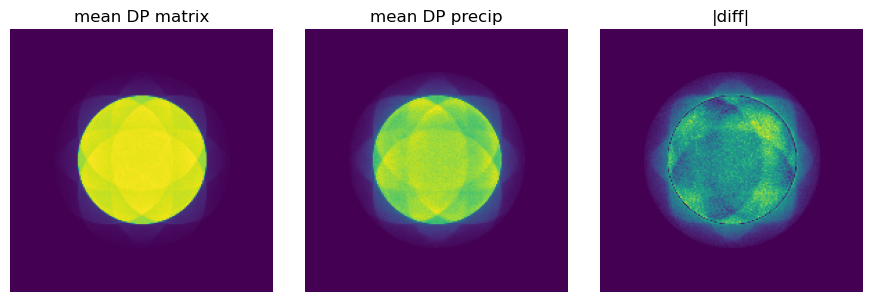

pf.detect_phases_multi: (data: 'np.ndarray', n_clusters: 'int' = 2, method: 'str' = 'kmeans', radial_bins: 'int | None' = 150, feature_set: 'str | list[str]' = 'all', verbose: 'bool' = False) -> 'dict[str, np.ndarray]'
p.run_pipeline: (data4d, nbins=20, exclude_low_q=0, n_pca=10, pca_use=5, method='kmeans', k=2, random_state=0)

Functions in pipelinefinalproject containing 'detect' or 'phase':
['detect_phases', 'detect_phases_multi']

Functions in pipeline containing 'run' or 'pipeline':
['run_pipeline']


In [28]:
# Sanity check: confirm the precipitate region has a measurably different mean diffraction pattern vs matrix.

import numpy as np
import matplotlib.pyplot as plt

data = np.load(OUTDIR / "abtem_precip.npy")             # (ny, nx, ky, kx)
mask = np.load(OUTDIR / "abtem_mask.npy").astype(bool)  # (ny, nx)

dp_in  = data[mask].mean(axis=0)                        # (ky, kx)
dp_out = data[~mask].mean(axis=0)                       # (ky, kx)

print("mean(dp_in)=", float(dp_in.mean()), "mean(dp_out)=", float(dp_out.mean()))
print("L1 diff (normalized)=", float(np.mean(np.abs(dp_in - dp_out)) / (dp_out.mean() + 1e-12)))

fig, axes = plt.subplots(1, 3, figsize=(9, 3))
axes[0].imshow(np.log1p(dp_out), origin="lower"); axes[0].set_title("mean DP matrix"); axes[0].axis("off")
axes[1].imshow(np.log1p(dp_in),  origin="lower"); axes[1].set_title("mean DP precip"); axes[1].axis("off")
axes[2].imshow(np.log1p(np.abs(dp_in - dp_out)), origin="lower"); axes[2].set_title("|diff|"); axes[2].axis("off")
plt.tight_layout()
plt.show()


# Compatibility check: confirm the actual function signatures in our pipeline scripts
# so we call them with the correct argument names.

import inspect
import pipelinefinalproject as pf
import pipeline as p

print("pf.detect_phases_multi:", inspect.signature(pf.detect_phases_multi))  # main abTEM evaluation entrypoint
print("p.run_pipeline:", inspect.signature(p.run_pipeline))                  # baseline radial-fingerprint pipeline

# List candidate functions in case the API name differs across versions/branches.
print("\nFunctions in pipelinefinalproject containing 'detect' or 'phase':")
print([name for name in dir(pf) if ("detect" in name.lower()) or ("phase" in name.lower())])

print("\nFunctions in pipeline containing 'run' or 'pipeline':")
print([name for name in dir(p) if ("run" in name.lower()) or ("pipeline" in name.lower())])

In [29]:
# Run our phase-detection pipeline on abTEM matrix-only and precipitate datasets,
# returning a (ny,nx) label map for each.

import numpy as np
import pipelinefinalproject as pf

X_mat = np.load(OUTDIR / "abtem_matrix.npy")
X_pre = np.load(OUTDIR / "abtem_precip.npy")
ny, nx = X_mat.shape[:2]

radial_bins = 40

res_mat = pf.detect_phases_multi(
    X_mat, n_clusters=2, method="gmm",
    radial_bins=radial_bins, feature_set=["radial"],
    verbose=True
)
res_pre = pf.detect_phases_multi(
    X_pre, n_clusters=2, method="gmm",
    radial_bins=radial_bins, feature_set=["radial"],
    verbose=True
)

labels_mat = res_mat["labels"].reshape(ny, nx)
labels_pre = res_pre["labels"].reshape(ny, nx)

print("labels_mat unique:", np.unique(labels_mat), "precip frac:", labels_mat.mean())
print("labels_pre unique:", np.unique(labels_pre), "precip frac:", labels_pre.mean())

Clustering 1024 patterns into 2 clusters using gmm with features ['radial']
Clustering 1024 patterns into 2 clusters using gmm with features ['radial']
labels_mat unique: [0 1] precip frac: 0.5
labels_pre unique: [0 1] precip frac: 0.0615234375


In [30]:
import numpy as np
import pipelinefinalproject as pf

X_pre = np.load(OUTDIR / "abtem_precip.npy")
gt    = np.load(OUTDIR / "abtem_mask.npy").astype(bool)
ny, nx = X_pre.shape[:2]

# Recompute labels with the stronger feature set
res_pre = pf.detect_phases_multi(
    X_pre, n_clusters=2, method="gmm",
    radial_bins=40, feature_set="all",
    verbose=False
)
labels_pre = res_pre["labels"].reshape(ny, nx)

def metrics(pred, gt):
    pred = pred.astype(bool); gt = gt.astype(bool)
    tp = np.logical_and(pred, gt).sum()
    fp = np.logical_and(pred, ~gt).sum()
    fn = np.logical_and(~pred, gt).sum()
    iou = tp / (tp + fp + fn + 1e-12)
    f1  = 2*tp / (2*tp + fp + fn + 1e-12)
    return float(iou), float(f1), int(tp), int(fp), int(fn)

m1 = metrics(labels_pre == 1, gt)
m0 = metrics(labels_pre == 0, gt)

print("GT precip frac:", gt.mean())
print("label==1 precip:", m1, "pred frac:", (labels_pre==1).mean())
print("label==0 precip:", m0, "pred frac:", (labels_pre==0).mean())
print("BEST:", "label==1" if m1[0] >= m0[0] else "label==0")

GT precip frac: 0.109375
label==1 precip: (0.04166666666666642, 0.07999999999999954, 7, 56, 105) pred frac: 0.0615234375
label==0 precip: (0.10847107438016518, 0.19571295433364383, 105, 856, 7) pred frac: 0.9384765625
BEST: label==0


In [31]:
# Ablation test: compare different feature groups on the same abTEM precipitate dataset
# and report IoU/F1 vs ground truth for each setting.

import numpy as np
import pipelinefinalproject as pf

X_pre = np.load(OUTDIR / "abtem_precip.npy")              # (ny, nx, ky, kx)
gt = np.load(OUTDIR / "abtem_mask.npy").astype(bool)      # (ny, nx)
ny, nx = X_pre.shape[:2]

def metrics(pred, gt):
    pred = pred.astype(bool)
    gt = gt.astype(bool)
    tp = np.logical_and(pred, gt).sum()
    fp = np.logical_and(pred, ~gt).sum()
    fn = np.logical_and(~pred, gt).sum()
    iou = tp / (tp + fp + fn + 1e-12)
    f1  = 2 * tp / (2 * tp + fp + fn + 1e-12)
    return float(iou), float(f1), int(tp), int(fp), int(fn)

def run(feature_set, radial_bins=40):
    res = pf.detect_phases_multi(
        X_pre, n_clusters=2, method="gmm",
        radial_bins=radial_bins, feature_set=feature_set, verbose=False
    )
    labels = res["labels"].reshape(ny, nx)

    m1 = metrics(labels == 1, gt)
    m0 = metrics(labels == 0, gt)

    best = m1 if m1[0] >= m0[0] else m0
    best_mask = (labels == (1 if m1[0] >= m0[0] else 0))
    return best, best_mask

tests = [
    ("radial", ["radial"]),
    ("radial+bf_df", ["radial", "bf_df"]),
    ("radial+anisotropy", ["radial", "anisotropy"]),
    ("radial+com", ["radial", "com"]),
    ("all", "all"),
]

for name, fs in tests:
    best, _ = run(fs, radial_bins=40)
    print(name, "IoU/F1/TP/FP/FN =", best)

radial IoU/F1/TP/FP/FN = (0.10847107438016518, 0.19571295433364383, 105, 856, 7)
radial+bf_df IoU/F1/TP/FP/FN = (0.12658227848101233, 0.224719101123595, 50, 283, 62)
radial+anisotropy IoU/F1/TP/FP/FN = (0.11754385964912259, 0.2103610675039243, 67, 458, 45)
radial+com IoU/F1/TP/FP/FN = (0.10847107438016518, 0.19571295433364383, 105, 856, 7)
all IoU/F1/TP/FP/FN = (0.10847107438016518, 0.19571295433364383, 105, 856, 7)


In [32]:
# Hyperparameter sweep: test clustering method and radial_bins on the abTEM precip dataset,
# and also record what the same settings do on the matrix-only negative control.

import numpy as np
import pipelinefinalproject as pf

X_mat = np.load(OUTDIR / "abtem_matrix.npy")              # matrix-only (ny,nx,ky,kx)
X_pre = np.load(OUTDIR / "abtem_precip.npy")              # precipitate case (ny,nx,ky,kx)
gt    = np.load(OUTDIR / "abtem_mask.npy").astype(bool)   # ground truth precip mask (ny,nx)

ny, nx = X_pre.shape[:2]

def metrics(pred, gt):
    pred = pred.astype(bool)
    gt = gt.astype(bool)
    tp = np.logical_and(pred, gt).sum()
    fp = np.logical_and(pred, ~gt).sum()
    fn = np.logical_and(~pred, gt).sum()
    iou = tp / (tp + fp + fn + 1e-12)
    f1  = 2 * tp / (2 * tp + fp + fn + 1e-12)
    return float(iou), float(f1), int(tp), int(fp), int(fn)

def best_mapping(labels_map, gt):
    m1 = metrics(labels_map == 1, gt)
    m0 = metrics(labels_map == 0, gt)
    return (1, m1) if m1[0] >= m0[0] else (0, m0)

radial_bins_list = [10, 20, 30, 40, 60]
methods = ["kmeans", "gmm"]

print("GT precip frac:", gt.mean())
print("cols: method, radial_bins, best_label, IoU, F1, TP, FP, FN, pred_frac_pre, pred_frac_mat")

for method in methods:
    for rb in radial_bins_list:
        res_pre = pf.detect_phases_multi(
            X_pre, n_clusters=2, method=method,
            radial_bins=rb, feature_set="all", verbose=False
        )
        labels_pre = res_pre["labels"].reshape(ny, nx)
        best_lab, (iou, f1, tp, fp, fn) = best_mapping(labels_pre, gt)
        pred_frac_pre = (labels_pre == best_lab).mean()

        res_mat = pf.detect_phases_multi(
            X_mat, n_clusters=2, method=method,
            radial_bins=rb, feature_set="all", verbose=False
        )
        labels_mat = res_mat["labels"].reshape(ny, nx)
        pred_frac_mat = (labels_mat == 1).mean()

        print(method, rb, best_lab, f"{iou:.4f}", f"{f1:.4f}", tp, fp, fn,
              f"{pred_frac_pre:.3f}", f"{pred_frac_mat:.3f}")

GT precip frac: 0.109375
cols: method, radial_bins, best_label, IoU, F1, TP, FP, FN, pred_frac_pre, pred_frac_mat
kmeans 10 0 0.1146 0.2056 111 857 1 0.945 0.062
kmeans 20 0 0.1135 0.2039 110 857 2 0.944 0.062
kmeans 30 0 0.1095 0.1974 106 856 6 0.939 0.062
kmeans 40 0 0.1085 0.1957 105 856 7 0.938 0.062
kmeans 60 0 0.1085 0.1957 105 856 7 0.938 0.062
gmm 10 0 0.1005 0.1826 80 684 32 0.746 0.250
gmm 20 0 0.1206 0.2152 41 228 71 0.263 0.500
gmm 30 1 0.1222 0.2178 49 289 63 0.330 0.500
gmm 40 0 0.1085 0.1957 105 856 7 0.938 0.062
gmm 60 0 0.1029 0.1867 35 228 77 0.257 0.500


In [33]:
# Final abTEM evaluation run: generate prediction masks, save report figures, and write a JSON summary.

import json
import numpy as np
import matplotlib.pyplot as plt
import pipelinefinalproject as pf

# Load datasets + ground truth.
X_mat = np.load(OUTDIR / "abtem_matrix.npy")
X_pre = np.load(OUTDIR / "abtem_precip.npy")
gt    = np.load(OUTDIR / "abtem_mask.npy").astype(bool)

ny, nx = X_pre.shape[:2]

def metrics(pred, gt):
    pred = pred.astype(bool)
    gt = gt.astype(bool)
    tp = np.logical_and(pred, gt).sum()
    fp = np.logical_and(pred, ~gt).sum()
    fn = np.logical_and(~pred, gt).sum()
    iou = tp / (tp + fp + fn + 1e-12)
    f1  = 2 * tp / (2 * tp + fp + fn + 1e-12)
    precision = tp / (tp + fp + 1e-12)
    recall    = tp / (tp + fn + 1e-12)
    return {
        "IoU": float(iou),
        "F1": float(f1),
        "precision": float(precision),
        "recall": float(recall),
        "TP": int(tp),
        "FP": int(fp),
        "FN": int(fn),
    }

def best_mapping(labels_map, gt):
    m1 = metrics(labels_map == 1, gt)
    m0 = metrics(labels_map == 0, gt)
    return (1, m1) if m1["IoU"] >= m0["IoU"] else (0, m0)

def save_mask_png(mask, fname, title=None):
    plt.figure(figsize=(4, 4))
    plt.imshow(mask, origin="lower")
    if title:
        plt.title(title)
    plt.axis("off")
    plt.tight_layout(pad=0.2)
    plt.savefig(fname, dpi=200)
    plt.close()

# --- chosen settings ---
method = "gmm"
radial_bins = 40
feature_set = "all"

# --- precip run ---
res_pre = pf.detect_phases_multi(
    X_pre, n_clusters=2, method=method,
    radial_bins=radial_bins, feature_set=feature_set, verbose=False
)
labels_pre = res_pre["labels"].reshape(ny, nx)

best_lab, met = best_mapping(labels_pre, gt)
pred = (labels_pre == best_lab)

# --- matrix-only run (negative control) ---
res_mat = pf.detect_phases_multi(
    X_mat, n_clusters=2, method=method,
    radial_bins=radial_bins, feature_set=feature_set, verbose=False
)
labels_mat = res_mat["labels"].reshape(ny, nx)

# --- save outputs ---
np.save(OUTDIR / "abtem_pred_mask.npy", pred.astype(np.uint8))
np.save(OUTDIR / "abtem_labels_matrix.npy", labels_mat.astype(np.int32))

xor = np.logical_xor(pred, gt)

save_mask_png(gt.astype(int),   OUTDIR / "abtem_gt_mask.png",   "GT mask")
save_mask_png(pred.astype(int), OUTDIR / "abtem_pred_mask.png", "Pred mask")
save_mask_png(xor.astype(int),  OUTDIR / "abtem_xor.png",       "XOR (error)")

plt.figure(figsize=(4, 4))
plt.imshow(pred.astype(int), origin="lower")
plt.contour(gt.astype(int), levels=[0.5], linewidths=1)
plt.title("Pred with GT contour")
plt.axis("off")
plt.tight_layout(pad=0.2)
plt.savefig(OUTDIR / "abtem_overlay.png", dpi=200)
plt.close()

report = {
    "settings": {"method": method, "radial_bins": radial_bins, "feature_set": feature_set},
    "gt_precip_fraction": float(gt.mean()),
    "pred_precip_fraction": float(pred.mean()),
    "best_label_mapping": int(best_lab),
    "metrics": met,
    "matrix_only_cluster_fraction_label1": float((labels_mat == 1).mean()),
    "matrix_only_unique_labels": [int(x) for x in np.unique(labels_mat)],
}

with open(OUTDIR / "abtem_results.json", "w") as f:
    json.dump(report, f, indent=2)

print("Saved:")
print("-", OUTDIR / "abtem_pred_mask.npy", OUTDIR / "abtem_labels_matrix.npy")
print("-", OUTDIR / "abtem_gt_mask.png", OUTDIR / "abtem_pred_mask.png", OUTDIR / "abtem_xor.png", OUTDIR / "abtem_overlay.png")
print("-", OUTDIR / "abtem_results.json")
print("Metrics:", met)
print("Matrix-only label==1 fraction:", report["matrix_only_cluster_fraction_label1"])

Saved:
- abtem_noise_outputs/abtem_pred_mask.npy abtem_noise_outputs/abtem_labels_matrix.npy
- abtem_noise_outputs/abtem_gt_mask.png abtem_noise_outputs/abtem_pred_mask.png abtem_noise_outputs/abtem_xor.png abtem_noise_outputs/abtem_overlay.png
- abtem_noise_outputs/abtem_results.json
Metrics: {'IoU': 0.10847107438016518, 'F1': 0.19571295433364383, 'precision': 0.10926118626430789, 'recall': 0.9374999999999917, 'TP': 105, 'FP': 856, 'FN': 7}
Matrix-only label==1 fraction: 0.0625


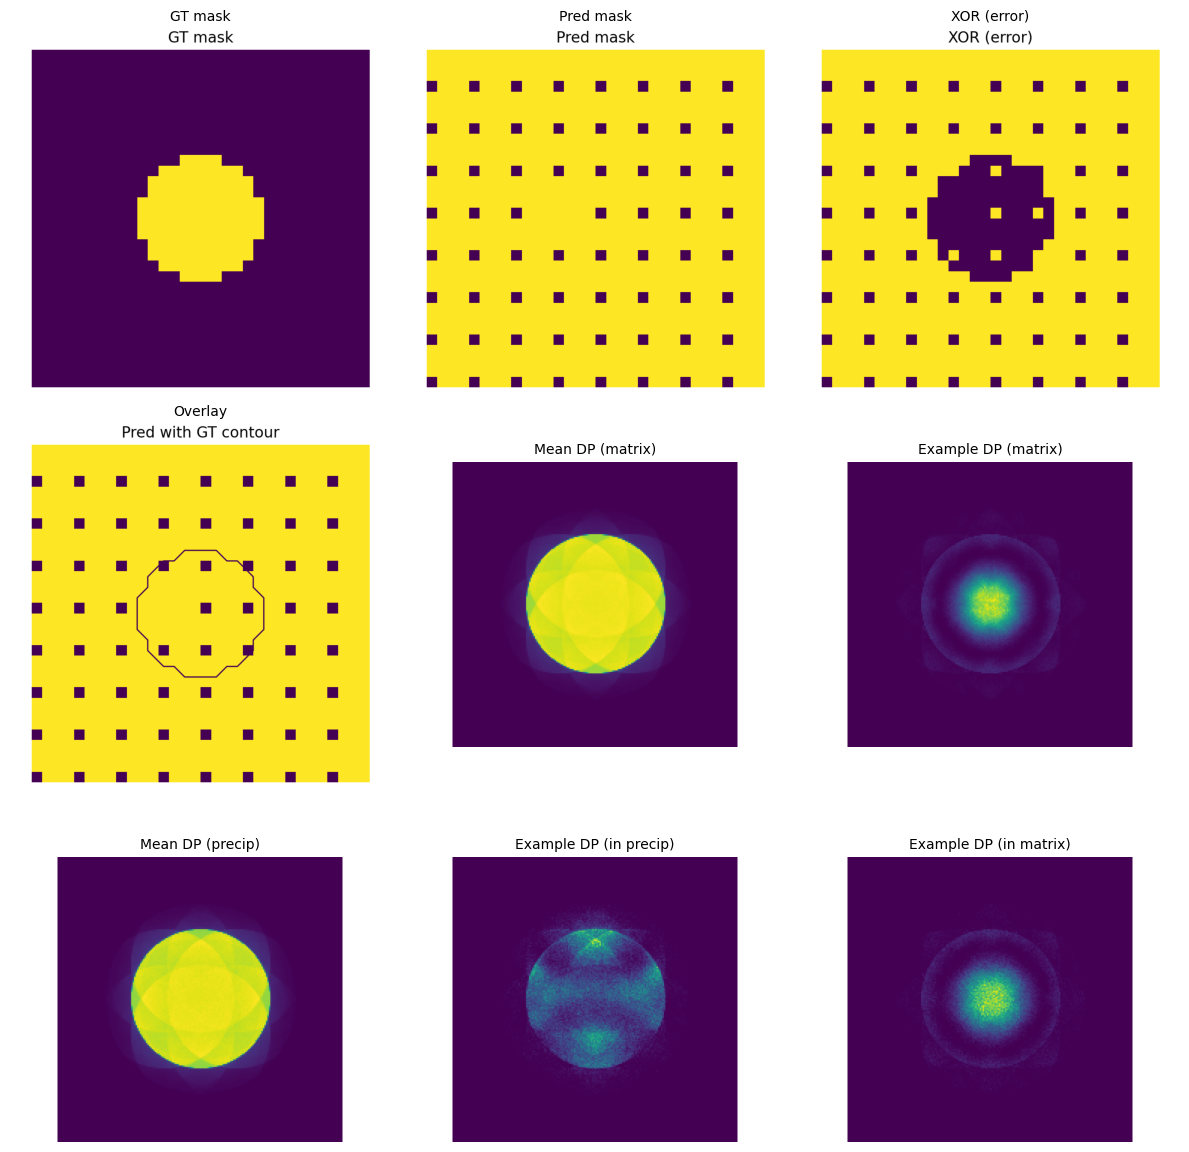

In [34]:
# Display all saved summary figures in a single grid (quick report sanity check).

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path


files = [
    ("GT mask", OUTDIR / "abtem_gt_mask.png"),
    ("Pred mask", OUTDIR / "abtem_pred_mask.png"),
    ("XOR (error)", OUTDIR / "abtem_xor.png"),
    ("Overlay", OUTDIR / "abtem_overlay.png"),
    ("Mean DP (matrix)", OUTDIR / "mean_dp_matrix.png"),
    ("Example DP (matrix)", OUTDIR / "example_dp_matrix.png"),
    ("Mean DP (precip)", OUTDIR / "mean_dp_precip.png"),
    ("Example DP (in precip)", OUTDIR / "example_dp_in_precip.png"),
    ("Example DP (in matrix)", OUTDIR / "example_dp_in_matrix.png"),
]

# Arrange images into a readable grid.
n = len(files)
cols = 3
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows))
axes = axes.ravel()

for ax, (title, path) in zip(axes, files):
    img = mpimg.imread(path)
    ax.imshow(img)
    ax.set_title(title, fontsize=10)
    ax.axis("off")

# Hide unused subplot slots.
for ax in axes[len(files):]:
    ax.axis("off")

plt.tight_layout()
plt.show()